# 01 — Transfer curves from Global-6 to sensor 7

The global model and architecture are loaded from Notebook 00. This notebook then:

1. uses sensor 6 once as an example slave;
2. selects the transfer learning rate and DS/PDS settings on that example;
3. freezes these choices;
4. repeats the final sensor-7 transfer with 5, 10, 20, and 40 adaptation UGMs.

This makes the benefit of additional transfer data visible. Every input contains subsensor 0 only, and all transfer steps are executed directly in the notebook.

In [1]:
from pathlib import Path
import sys, json, numpy as np, matplotlib.pyplot as plt
ROOT=next(p for p in (Path.cwd().resolve(),*Path.cwd().resolve().parents)
          if (p/"Networks"/"TCOCNNv3.py").exists())
sys.path[:0]=[str(ROOT/"Networks"),str(ROOT/"Evaluation Seminar"/"Day_03"),
              str(ROOT/"Evaluation Seminar"/"Day_04")]
from day4_utils import (load_checkpoint,load_sensor_domains,scale_domain,
                        transfer_subset,fit_network,predict_ppb,save_checkpoint)
from transfer_workflow import *

GLOBAL=ROOT/"artifacts"/"seminar_day4_global6_hpo"/"source_global6_hpo"
OUTPUT=ROOT/"artifacts"/"seminar_day4_transfer"; OUTPUT.mkdir(parents=True,exist_ok=True)
global_model,scaler,metadata=load_checkpoint(GLOBAL)
raw,audit=load_sensor_domains(channel=0,calibration=1,gas="acetone")
sensors=list(raw); masters,target=sensors[:6],sensors[6]
domains={sensor:scale_domain(raw[sensor],scaler) for sensor in sensors}
assert all(domains[s][split]["X_z"].shape[1:]==(1,1440,1)
           for s in sensors for split in ["train","val","test"])

SEED=42
BUDGETS=[5,10,20,40]
EXAMPLE_BUDGET=20
LR_CANDIDATES=[3e-7,1e-6,3e-6,1e-5]
FINE_TUNE_EPOCHS=5
print("Loaded Global-6. Masters:",masters,"| target:",target)
print("Transfer budgets:",BUDGETS,"UGMs | one subsensor per cycle")

Loaded Global-6. Masters: ['54118801', '54120037', '54120457', '54156953', '84746449', '84748697'] | target: 84749569
Transfer budgets: [5, 10, 20, 40] UGMs | one subsensor per cycle


## The synchronized master/slave problem

The same physical cycle is available from all devices. The six masters remain separate observations; they are never averaged into a virtual master.

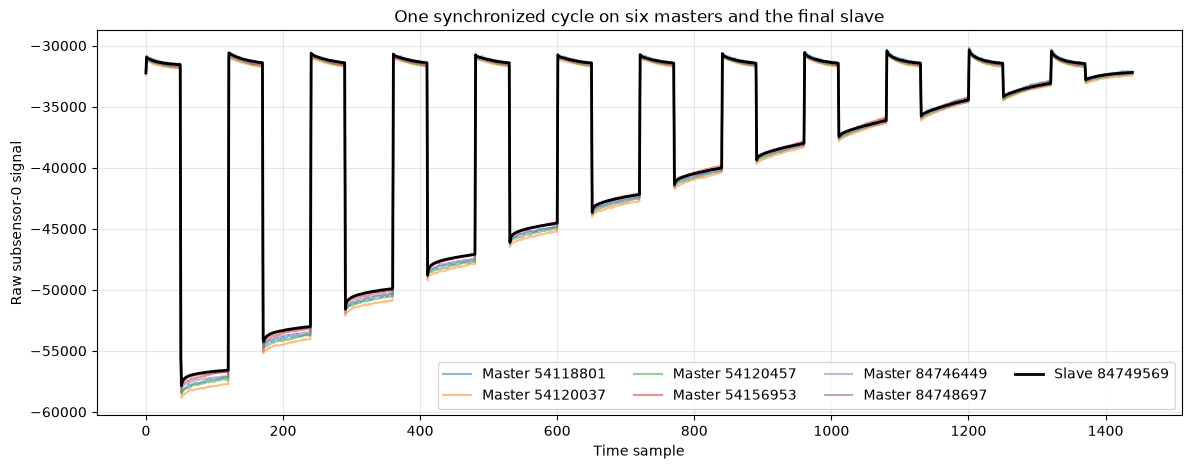

In [2]:
fig,ax=plt.subplots(figsize=(14,5))
for sensor in masters:
    ax.plot(raw[sensor]["train"]["X"][0,0,:,0],alpha=.5,label=f"Master {sensor}")
ax.plot(raw[target]["train"]["X"][0,0,:,0],color="black",lw=2,label=f"Slave {target}")
ax.set(title="One synchronized cycle on six masters and the final slave",
       xlabel="Time sample",ylabel="Raw subsensor-0 signal")
ax.legend(ncol=4); ax.grid(True,alpha=.3); plt.show()

## Select transfer settings on one example sensor

Sensor 6 is used once as the pseudo-slave and sensors 1–5 are its masters. The global architecture is fixed, but the transfer learning rate is selected here. DS and PDS are fitted to all individual master/slave regression rows.

In [3]:
example_slave=masters[-1]; example_masters=masters[:-1]
example=transfer_subset(domains[example_slave],EXAMPLE_BUDGET,seed=SEED)
example_x,example_y,example_ids=aligned_master_slave_pairs(
    domains,example_masters,example)
print(len(example["train"]["X_z"]),"slave cycles produce",len(example_x),
      "individual master/slave regression rows")

lr_rows=[]
for lr in LR_CANDIDATES:
    params={**metadata["params"],"initial_learning_rate":lr}
    candidate,_,_=fit_network(
        example,params,epochs=FINE_TUNE_EPOCHS,initial=copy_state(global_model),
        freeze_batchnorm=True,restore_best=False,use_validation=False,
        lr_schedule="constant",seed=SEED,verbose=False)
    pred=predict_ppb(candidate,domains[example_slave]["val"],scaler)
    lr_rows.append({"learning_rate":lr,
                    **metrics(domains[example_slave]["val"]["y"],pred,
                              domains[example_slave]["val"]["groups"])})
selected_lr=min(lr_rows,key=lambda row:row["UGM_RMSE_ppb"])["learning_rate"]

adapter_rows=[]
for alpha in [.01,.1,1.]:
    candidates=[("DS",None,DirectStandardization(alpha)),
                ("PDS",2,PiecewiseDirectStandardization(alpha,2)),
                ("PDS",4,PiecewiseDirectStandardization(alpha,4))]
    for name,radius,adapter in candidates:
        adapter.fit(example_x,example_y)
        pred=mapped_predictions(global_model,adapter,domains[example_slave]["val"],scaler)
        adapter_rows.append({"method":name,"alpha":alpha,"radius":radius,
                             **metrics(domains[example_slave]["val"]["y"],pred,
                                       domains[example_slave]["val"]["groups"])})
best_ds=min((r for r in adapter_rows if r["method"]=="DS"),
            key=lambda r:r["UGM_RMSE_ppb"])
best_pds=min((r for r in adapter_rows if r["method"]=="PDS"),
             key=lambda r:r["UGM_RMSE_ppb"])
try:
    import pandas as pd
    display(pd.DataFrame(lr_rows))
    display(pd.DataFrame(adapter_rows).sort_values(["method","UGM_RMSE_ppb"]))
except ImportError:
    print(lr_rows); print(adapter_rows)
print("Frozen transfer learning rate:",selected_lr)
print("Frozen DS/PDS settings:",best_ds,best_pds)

90 slave cycles produce 450 individual master/slave regression rows
[{'learning_rate': 3e-07, 'UGM_RMSE_ppb': 25.4680917793814, 'UGM_R2': 0.8938091712464119, 'UGMs': 19}, {'learning_rate': 1e-06, 'UGM_RMSE_ppb': 35.453660613686154, 'UGM_R2': 0.7942137449990591, 'UGMs': 19}, {'learning_rate': 3e-06, 'UGM_RMSE_ppb': 58.028338664734974, 'UGM_R2': 0.4487171631985084, 'UGMs': 19}, {'learning_rate': 1e-05, 'UGM_RMSE_ppb': 150.08177000047576, 'UGM_R2': -2.6876533008852617, 'UGMs': 19}]
[{'method': 'DS', 'alpha': 0.01, 'radius': None, 'UGM_RMSE_ppb': 64.40097912881681, 'UGM_R2': 0.32098535974646836, 'UGMs': 19}, {'method': 'PDS', 'alpha': 0.01, 'radius': 2, 'UGM_RMSE_ppb': 68.94538576871447, 'UGM_R2': 0.2217760188295569, 'UGMs': 19}, {'method': 'PDS', 'alpha': 0.01, 'radius': 4, 'UGM_RMSE_ppb': 71.79310851323763, 'UGM_R2': 0.15616076670167633, 'UGMs': 19}, {'method': 'DS', 'alpha': 0.1, 'radius': None, 'UGM_RMSE_ppb': 73.07327025892855, 'UGM_R2': 0.12579902738241766, 'UGMs': 19}, {'method': 'P

C:\Users\yanni\AppData\Local\Temp\ipykernel_30024\4085780033.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  for ax in axes: ax.grid(True,alpha=.3); ax.legend()


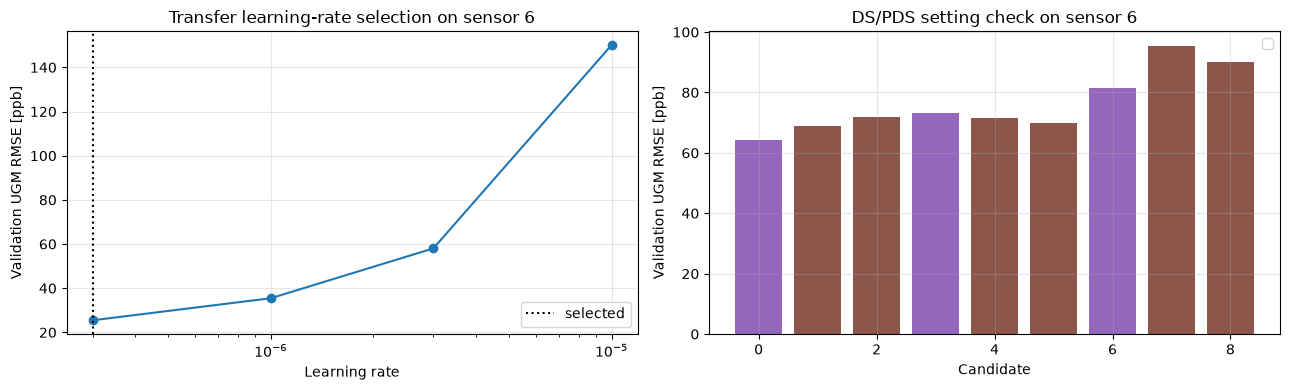

In [4]:
fig,axes=plt.subplots(1,2,figsize=(13,4))
axes[0].semilogx([r["learning_rate"] for r in lr_rows],
                 [r["UGM_RMSE_ppb"] for r in lr_rows],marker="o")
axes[0].axvline(selected_lr,color="black",ls=":",label="selected")
axes[0].set(title="Transfer learning-rate selection on sensor 6",
            xlabel="Learning rate",ylabel="Validation UGM RMSE [ppb]")
axes[1].bar(range(len(adapter_rows)),[r["UGM_RMSE_ppb"] for r in adapter_rows],
            color=["#9467bd" if r["method"]=="DS" else "#8c564b" for r in adapter_rows])
axes[1].set(title="DS/PDS setting check on sensor 6",
            xlabel="Candidate",ylabel="Validation UGM RMSE [ppb]")
for ax in axes: ax.grid(True,alpha=.3); ax.legend()
plt.tight_layout(); plt.show()

## Final transfer curves on sensor 7

The settings above are now frozen. For every budget, the notebook refits DS/PDS and starts fine-tuning from the same saved Global-6 weights. Transfer subsets are nested: the 5-UGM subset is contained in the 10-, 20-, and 40-UGM subsets.

In [5]:
results=[]; predictions={}; trained_models={}; histories={}
for split in ["val","test"]:
    baseline=predict_ppb(global_model,domains[target][split],scaler)
    results.append({"budget_UGMs":0,"split":split,"method":"Global-6",
                    **metrics(domains[target][split]["y"],baseline,
                              domains[target][split]["groups"])})

for budget in BUDGETS:
    subset=transfer_subset(domains[target],budget,seed=SEED)
    slave_x,master_y,master_ids=aligned_master_slave_pairs(domains,masters,subset)
    ds=DirectStandardization(best_ds["alpha"]).fit(slave_x,master_y)
    pds=PiecewiseDirectStandardization(
        best_pds["alpha"],best_pds["radius"]).fit(slave_x,master_y)
    params={**metadata["params"],"initial_learning_rate":selected_lr}
    fine,history,_=fit_network(
        subset,params,epochs=FINE_TUNE_EPOCHS,initial=copy_state(global_model),
        freeze_batchnorm=True,restore_best=False,use_validation=False,
        lr_schedule="constant",seed=SEED,verbose=False)
    trained_models[budget]=fine; histories[budget]=history
    for split in ["val","test"]:
        current={"Fine-tune":predict_ppb(fine,domains[target][split],scaler),
                 "DS":mapped_predictions(global_model,ds,domains[target][split],scaler),
                 "PDS":mapped_predictions(global_model,pds,domains[target][split],scaler)}
        predictions[(budget,split)]=current
        for name,pred in current.items():
            results.append({"budget_UGMs":budget,"split":split,"method":name,
                            **metrics(domains[target][split]["y"],pred,
                                      domains[target][split]["groups"])})
    print(f"Completed {budget} UGMs: {len(subset['train']['X_z'])} cycles, "
          f"{len(slave_x)} DS/PDS regression rows")

Completed 5 UGMs: 22 cycles, 132 DS/PDS regression rows
Completed 10 UGMs: 45 cycles, 270 DS/PDS regression rows
Completed 20 UGMs: 90 cycles, 540 DS/PDS regression rows
Completed 40 UGMs: 175 cycles, 1050 DS/PDS regression rows


## More transfer data: improvement curves and final scatter

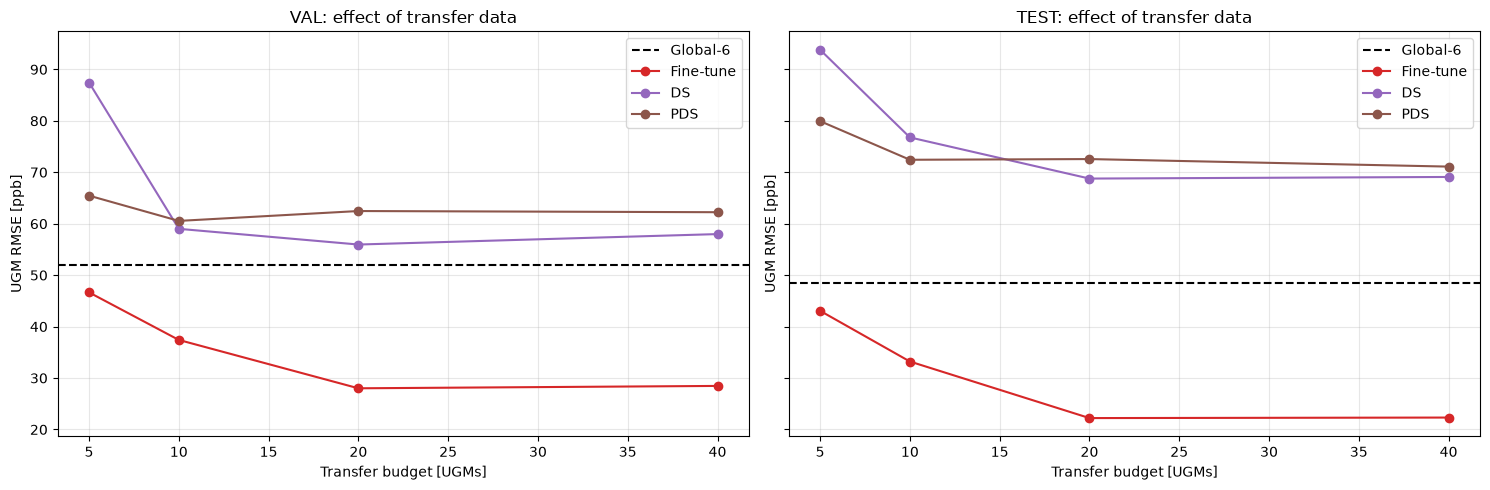

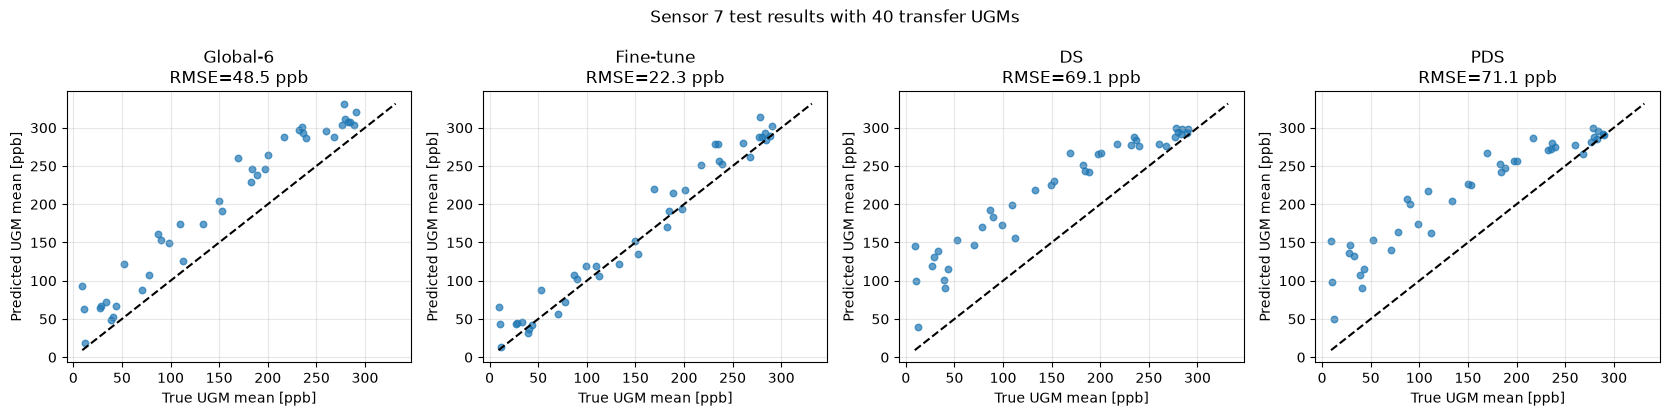

[{'budget_UGMs': 0,
  'split': 'val',
  'method': 'Global-6',
  'UGM_RMSE_ppb': 51.92877380659941,
  'UGM_R2': 0.5585207123292161,
  'UGMs': 19},
 {'budget_UGMs': 0,
  'split': 'test',
  'method': 'Global-6',
  'UGM_RMSE_ppb': 48.52398934463439,
  'UGM_R2': 0.7412490222920403,
  'UGMs': 40},
 {'budget_UGMs': 5,
  'split': 'val',
  'method': 'Fine-tune',
  'UGM_RMSE_ppb': 46.65028475325873,
  'UGM_R2': 0.6437106870186675,
  'UGMs': 19},
 {'budget_UGMs': 5,
  'split': 'val',
  'method': 'DS',
  'UGM_RMSE_ppb': 87.44989352516966,
  'UGM_R2': -0.2520243281839538,
  'UGMs': 19},
 {'budget_UGMs': 5,
  'split': 'val',
  'method': 'PDS',
  'UGM_RMSE_ppb': 65.45868171155858,
  'UGM_R2': 0.2984983334999024,
  'UGMs': 19},
 {'budget_UGMs': 5,
  'split': 'test',
  'method': 'Fine-tune',
  'UGM_RMSE_ppb': 43.067554618131915,
  'UGM_R2': 0.7961693786249231,
  'UGMs': 40},
 {'budget_UGMs': 5,
  'split': 'test',
  'method': 'DS',
  'UGM_RMSE_ppb': 93.81983081725735,
  'UGM_R2': 0.0327064474337323,
  '

In [6]:
fig,axes=plt.subplots(1,2,figsize=(15,5),sharey=True)
for ax,split in zip(axes,["val","test"]):
    baseline=next(r["UGM_RMSE_ppb"] for r in results
                  if r["method"]=="Global-6" and r["split"]==split)
    ax.axhline(baseline,color="black",ls="--",label="Global-6")
    for method,color in [("Fine-tune","#d62728"),("DS","#9467bd"),("PDS","#8c564b")]:
        rows=[r for r in results if r["method"]==method and r["split"]==split]
        ax.plot([r["budget_UGMs"] for r in rows],[r["UGM_RMSE_ppb"] for r in rows],
                marker="o",label=method,color=color)
    ax.set(title=f"{split.upper()}: effect of transfer data",
           xlabel="Transfer budget [UGMs]",ylabel="UGM RMSE [ppb]")
    ax.grid(True,alpha=.3); ax.legend()
plt.tight_layout(); plt.show()

largest=max(BUDGETS)
final_predictions={"Global-6":predict_ppb(global_model,domains[target]["test"],scaler),
                   **predictions[(largest,"test")]}
scatter_grid(domains[target]["test"],final_predictions,
             f"Sensor 7 test results with {largest} transfer UGMs")
display(pd.DataFrame(results) if "pd" in globals() else results)

## Save the largest-budget model for XAI

Notebook 02 receives the exact 40-UGM subset, the selected learning rate, and the same source checkpoint. Its partial-cycle models can therefore use precisely the transfer configuration selected here.

In [7]:
xai_budget=max(BUDGETS)
xai_subset=transfer_subset(domains[target],xai_budget,seed=SEED)
groups=np.unique(xai_subset["train"]["groups"]).astype(int).tolist()
params={**metadata["params"],"initial_learning_rate":selected_lr}
config={"masters":masters,"target":target,"channel":0,"budgets_UGMs":BUDGETS,
        "xai_budget_UGMs":xai_budget,"selected_groups":groups,
        "example_slave":example_slave,"selected_learning_rate":selected_lr,
        "fine_tune_epochs":FINE_TUNE_EPOCHS,
        "DS":{"alpha":best_ds["alpha"]},
        "PDS":{"alpha":best_pds["alpha"],"radius":best_pds["radius"]},
        "pairing":"all individual master cycles; no master mean"}
save_checkpoint(OUTPUT/"target_finetuned",trained_models[xai_budget],scaler,
                {**metadata,**config,"params":params},
                xai_subset["train"]["X_z"].mean(0,keepdims=True))
save_json(OUTPUT/"transfer_config.json",config)
save_json(OUTPUT/"metrics.json",results)
save_json(OUTPUT/"learning_rate_search.json",lr_rows)
print("Saved final transfer and XAI hand-off:",OUTPUT)

Saved final transfer and XAI hand-off: \\ROBNEXUS\Home\GIT\TCOCNN_PY\artifacts\seminar_day4_transfer
